In [5]:
# Helper cell: set up imports and paths for modules

import sys

modules_path = "/home/stages/chau/projects/internship-bezout/src/modules"
if modules_path not in sys.path:
    sys.path.insert(0, modules_path)

import importlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta
from scipy.stats import entropy, wasserstein_distance, gaussian_kde

import stochastic_recurrence
import solver
import monte_carlo
import operators

importlib.reload(stochastic_recurrence)
importlib.reload(solver)
importlib.reload(monte_carlo)
importlib.reload(operators)

from stochastic_recurrence import simulate_Yns_independent, simulate_Yns, simulate_Yns_numba, compute_Yns_numba
from solver import mean_preserving_alpha
from monte_carlo import plot_distribution, sample_from_empirical, MeanOneGenerator, less_than_in_convex_order
from operators import T, Phi, S


In [ ]:
num_particles = 1000000
u = 0.5
v = 0.3
op = lambda x,a: T(x, u, v, a) 
alpha = 0

X = np.ones(num_particles)

for i in range(20):
    alpha = mean_preserving_alpha(X, op, bracket=[2*u+v-1, 2*(u+v)-1])
    X = op(X, alpha)
    print(f"Iteration {i+1}: alpha = {alpha:.4f}")

In [7]:
print(alpha)

0.47681946110067025


In [8]:
# Start from alpha a little bigger to see if the sequence converges to zero
alpha = 0.48
num_particles = 1000000
u = 0.5
v = 0.3

op = lambda x,a: T(x, u, v, a)
Z = np.ones(num_particles)

history = [Z]

for i in range(500):
    Z = op(Z, alpha)
    history.append(Z)
    if (i + 1) % 100 == 0:
      print(f"Iteration {i+1}: mean = {np.mean(Z)}, second moment = {np.mean(Z**2)}")



Iteration 100: mean = 0.7187878215244102, second moment = 0.987732962950248
Iteration 200: mean = 0.5925469168456727, second moment = 0.6710698126789602
Iteration 300: mean = 0.4980954672279598, second moment = 0.474074808603179
Iteration 400: mean = 0.4200657035296485, second moment = 0.33663603372541595
Iteration 500: mean = 0.34940827835167726, second moment = 0.23306041551849577


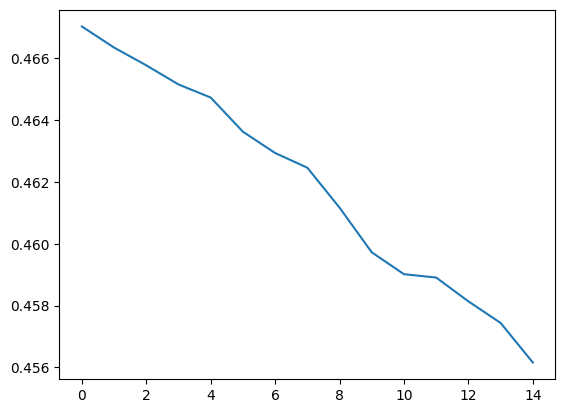

In [21]:
means = [np.mean(Z) for Z in history]
plt.plot(means[340:355])

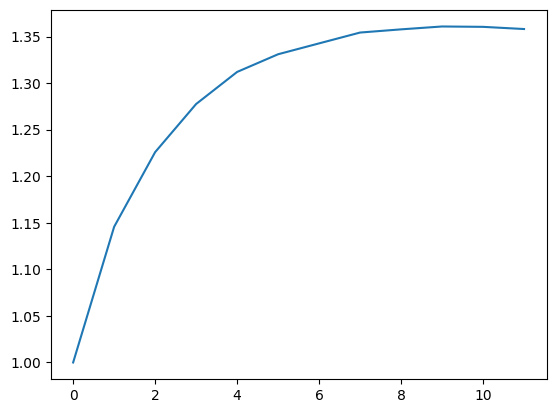

In [10]:
plt.plot(moments[:12])

In [11]:
# Start from alpha a little smaller to see if the sequence converges to zero
alpha = 0.47
num_particles = 1000000
u = 0.5
v = 0.3

op = lambda x,a: T(x, u, v, a)
Z = np.ones(num_particles)

means = [1]
moments = [1]

for i in range(2000):
    Z = op(Z, alpha)
    means.append(np.mean(Z))
    moments.append(np.mean(Z**2))
    if (i + 1) % 100 == 0:
      print(f"Iteration {i+1}: mean = {np.mean(Z)}, second moment = {np.mean(Z**2)}")

Iteration 100: mean = 1.3143039260381022, second moment = 3.285051934006461
Iteration 200: mean = 2.0130679126951176, second moment = 7.70540217127671
Iteration 300: mean = 3.068770877683629, second moment = 17.935321591811007
Iteration 400: mean = 4.686523907969945, second moment = 41.7915822765261
Iteration 500: mean = 7.208097335948536, second moment = 98.58124194146573
Iteration 600: mean = 10.976229759283218, second moment = 229.1558220618947
Iteration 700: mean = 16.9645489977333, second moment = 547.1982725747145
Iteration 800: mean = 25.733471003600354, second moment = 1261.831860474587
Iteration 900: mean = 39.59341064285695, second moment = 2984.952635477198
Iteration 1000: mean = 60.05497887575004, second moment = 6869.310099170359


KeyboardInterrupt: 

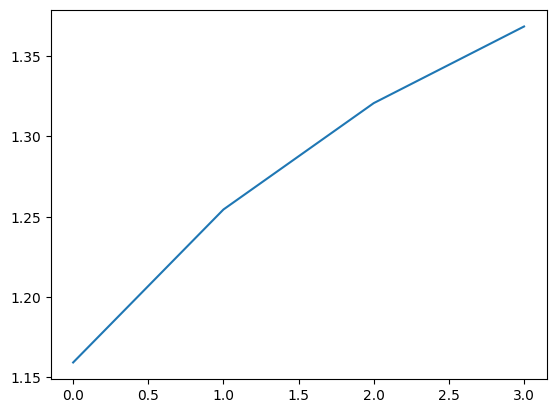

In [14]:
plt.plot(moments[1:5])

In [2]:
def continuous_entropy_kde(particles):
    kde = gaussian_kde(particles)
    log_pdf = kde.logpdf(particles)
    return -np.mean(log_pdf)

In [2]:
from scipy.spatial import cKDTree
from scipy.special import digamma

def knn_entropy_1d(particles, k=4):
    """
    Highly optimized 1D Kozachenko-Leonenko entropy estimator 
    for large particle systems (e.g., N = 10^6).
    
    Parameters:
    -----------
    particles : ndarray
        A 1D NumPy array of shape (N,) containing the particle coordinates.
    k : int
        The k-th nearest neighbor to query (default: 4).
    """
    N = len(particles)
    
    # 1. Reshape to (N, 1) for the cKDTree and construct the tree
    # Using compact_nodes=False speeds up tree build time for 1D uniform data
    tree = cKDTree(particles[:, np.newaxis], compact_nodes=False)
    
    # 2. Query distances using all available CPU threads (workers=-1)
    # k+1 because index 0 is the particle itself (distance 0)
    distances, _ = tree.query(particles[:, np.newaxis], k=k+1, workers=-1)
    
    # 3. Extract the k-th neighbor distances
    rho = distances[:, -1]
    
    # Guard against perfectly overlapping particles (avoid log(0))
    rho = np.where(rho == 0, 1e-15, rho)
    
    # 4. Evaluate the KL formula for d=1 (where log(V_1) = log(2))
    entropy = digamma(N) - digamma(k) + np.log(2.0) + (1.0 / N) * np.sum(np.log(rho))
    
    return entropy

In [3]:
alpha = 0.48
u = 0.5
v = 0.3

num_particles = 1000000
Z = np.ones(num_particles)
op = lambda x,a: T(x, u, v, a)

means = []
# supps = []
entropies = []
for i in range(100):
    Z = op(Z, alpha)
    means.append(np.mean(Z))
    # supps.append(np.max(Z))
    entropies.append(knn_entropy_1d(Z))
    if (i+1) % 1 == 0:
      print(f"Iteration {i+1}: E[Z] = {np.mean(Z):<15} | H(Z) = {entropies[-1]:<15}")

Iteration 1: E[Z] = 0.9359500999576352 | H(Z) = -4.74632780616308
Iteration 2: E[Z] = 0.9064626239930661 | H(Z) = -4.311760105672462
Iteration 3: E[Z] = 0.8895576953583257 | H(Z) = -4.3515535365620615
Iteration 4: E[Z] = 0.8778037589722472 | H(Z) = -4.385257912844327
Iteration 5: E[Z] = 0.8693949952021012 | H(Z) = -4.397769736966982
Iteration 6: E[Z] = 0.8634581588120528 | H(Z) = -4.384886639589354
Iteration 7: E[Z] = 0.8585039652422156 | H(Z) = -4.372063611458074
Iteration 8: E[Z] = 0.8564479966702975 | H(Z) = -4.373518072740705
Iteration 9: E[Z] = 0.8524224369282523 | H(Z) = -4.370159809102091
Iteration 10: E[Z] = 0.8493690945504702 | H(Z) = -4.372566896698945
Iteration 11: E[Z] = 0.8489652627999223 | H(Z) = -4.339008320286894
Iteration 12: E[Z] = 0.8457710328269783 | H(Z) = -4.366630561716608
Iteration 13: E[Z] = 0.8441364101445987 | H(Z) = -4.357781085576065
Iteration 14: E[Z] = 0.8423749334444474 | H(Z) = -4.350980146717575
Iteration 15: E[Z] = 0.8397352683297836 | H(Z) = -4.36398

In [5]:
def weighted_max(X, alpha):
  U = np.random.uniform(size=X.shape)
  X1 = sample_from_empirical(X)
  X2 = sample_from_empirical(X)
  return np.max([U**alpha * X1, (1-U)**alpha * X2], axis=0)

In [12]:
# Start from alpha a little bigger to see if the sequence converges to zero
alpha = 0.48
num_particles = 10000000
u = 0.5
v = 0.3

op = lambda x,a: T(x, u, v, a)

Z = np.ones(num_particles)
for i in range(30):
    Z_next = op(Z, alpha)
    
    print(f"Iteration {i+1}: E[Z] = {np.mean(Z):<15} | E[max(UZ_{i+1}, (1-U)Z_{i+1})] < E[max(UZ_{i}, (1-U)Z_{i})] = {np.mean(weighted_max(Z, alpha))-np.mean(weighted_max(Z_next, alpha))>0:<15}")    
    Z = Z_next



Iteration 1: E[Z] = 1.0             | E[max(UZ_1, (1-U)Z_1)] < E[max(UZ_0, (1-U)Z_0)] = 0              
Iteration 2: E[Z] = 0.9359352773094487 | E[max(UZ_2, (1-U)Z_2)] < E[max(UZ_1, (1-U)Z_1)] = 0              
Iteration 3: E[Z] = 0.9068956309216496 | E[max(UZ_3, (1-U)Z_3)] < E[max(UZ_2, (1-U)Z_2)] = 0              
Iteration 4: E[Z] = 0.8894572951375032 | E[max(UZ_4, (1-U)Z_4)] < E[max(UZ_3, (1-U)Z_3)] = 1              
Iteration 5: E[Z] = 0.878278900362019 | E[max(UZ_5, (1-U)Z_5)] < E[max(UZ_4, (1-U)Z_4)] = 1              
Iteration 6: E[Z] = 0.8707636099624648 | E[max(UZ_6, (1-U)Z_6)] < E[max(UZ_5, (1-U)Z_5)] = 1              
Iteration 7: E[Z] = 0.8649754198699972 | E[max(UZ_7, (1-U)Z_7)] < E[max(UZ_6, (1-U)Z_6)] = 1              
Iteration 8: E[Z] = 0.8606121505123504 | E[max(UZ_8, (1-U)Z_8)] < E[max(UZ_7, (1-U)Z_7)] = 1              
Iteration 9: E[Z] = 0.8575779669433314 | E[max(UZ_9, (1-U)Z_9)] < E[max(UZ_8, (1-U)Z_8)] = 1              
Iteration 10: E[Z] = 0.8546363970149785 |